<a href="https://www.kaggle.com/code/aamir28/cardiovascular-risk-factor-analysis?scriptVersionId=340930656" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:#FFFFFF; padding:44px 42px; border-radius:10px; border:1px solid #E3E8ED; box-shadow:0 8px 24px rgba(20,40,60,0.05); font-family:'Segoe UI',Helvetica,Arial,sans-serif;">

  <svg width="100%" height="46" viewBox="0 0 700 46" style="display:block; margin-bottom:14px;">
    <polyline points="0,23 120,23 140,23 150,5 160,40 170,10 180,23 220,23 240,23 250,8 260,38 270,23 320,23 700,23"
      fill="none" stroke="#D6455D" stroke-width="2.5"/>
  </svg>

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:10px;">
    <span style="background:#FCEBEE; color:#D6455D; font-size:11px; font-weight:700; padding:4px 12px; border-radius:20px; letter-spacing:0.5px;">CLINICAL DATA REVIEW</span>
    <span style="font-family:'Courier New',monospace; font-size:11px; color:#8B98A5;">n = 9,000 PATIENTS</span>
  </div>

  <h1 style="margin:0 0 8px 0; font-size:32px; color:#1C2B36; font-weight:700; letter-spacing:-0.3px;">
    Cardiovascular Risk Factor Analysis
  </h1>
  <p style="margin:0 0 26px 0; font-size:15px; color:#5B6B78; max-width:640px;">
    Clinical measurements, lifestyle factors, and diagnosed heart disease status across 9,000 patient records
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:14px;">
    <div style="background:#F7F9FA; border-radius:10px; padding:16px; text-align:center;">
      <div style="color:#D6455D; font-size:22px; font-weight:800;">30.3%</div>
      <div style="font-size:11px; color:#8B98A5; margin-top:2px;">disease prevalence</div>
    </div>
    <div style="background:#F7F9FA; border-radius:10px; padding:16px; text-align:center;">
      <div style="color:#2E6E8E; font-size:22px; font-weight:800;">26</div>
      <div style="font-size:11px; color:#8B98A5; margin-top:2px;">clinical &amp; lifestyle fields</div>
    </div>
    <div style="background:#F7F9FA; border-radius:10px; padding:16px; text-align:center;">
      <div style="color:#3B8C6E; font-size:22px; font-weight:800;">0</div>
      <div style="font-size:11px; color:#8B98A5; margin-top:2px;">missing values</div>
    </div>
    <div style="background:#F7F9FA; border-radius:10px; padding:16px; text-align:center;">
      <div style="color:#C98A2E; font-size:22px; font-weight:800;">18–90</div>
      <div style="font-size:11px; color:#8B98A5; margin-top:2px;">age range</div>
    </div>
  </div>

  <div style="margin-top:22px; padding:14px 18px; background:#FCEBEE; border-radius:8px; border-left:3px solid #D6455D;">
    <p style="margin:0; font-size:12.5px; color:#7A2C38; line-height:1.6;">
      <b>This notebook is exploratory and educational.</b> It studies patterns in a dataset and is not a diagnostic
      tool. Nothing here should be used to assess any individual's personal cardiovascular risk — that's a
      conversation for a doctor.
    </p>
  </div>

  <p style="margin:16px 0 0 0; font-size:12.5px; color:#8B98A5;">
    Author: <b style="color:#1C2B36;">Muhammad Aamir</b> &nbsp;|&nbsp; Target: <code>has_heart_disease</code>
  </p>

</div>



<div style="background:#F7F9FA; border-left:4px solid #D6455D; border-radius:8px; padding:20px 26px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36;">
<h3 style="margin-top:0; font-weight:700; color:#D6455D; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#D6455D; text-decoration:none;">Setup &amp; Clinical Styling</a></li>
<li><a href="#firstlook" style="color:#D6455D; text-decoration:none;">First Look at the Records</a></li>
<li><a href="#quality" style="color:#D6455D; text-decoration:none;">Data Quality Check</a></li>
<li><a href="#demo" style="color:#D6455D; text-decoration:none;">Demographic &amp; Risk Landscape</a></li>
<li><a href="#clinical" style="color:#D6455D; text-decoration:none;">Clinical Measurements Overview</a></li>
<li><a href="#drivers" style="color:#D6455D; text-decoration:none;">The Strongest Risk Signals</a></li>
<li><a href="#categorical" style="color:#D6455D; text-decoration:none;">Categorical Risk Factors</a></li>
<li><a href="#lifestyle" style="color:#D6455D; text-decoration:none;">Lifestyle Factors</a></li>
<li><a href="#corr" style="color:#D6455D; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#D6455D; text-decoration:none;">Clinical Dashboard</a></li>
<li><a href="#model" style="color:#D6455D; text-decoration:none;">Classifying Heart Disease Risk</a></li>
<li><a href="#conclusion" style="color:#D6455D; text-decoration:none;">Closing Notes</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">⚙️ 1. Setup &amp; Clinical Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Clinical Cardiology" palette ----
BG        = '#F7F9FA'
PANEL     = '#FFFFFF'
INK       = '#1C2B36'
INK_SOFT  = '#8B98A5'
RED       = '#D6455D'
BLUE      = '#2E6E8E'
GREEN     = '#3B8C6E'
AMBER     = '#C98A2E'
PURPLE    = '#7A5CA8'
GRID      = '#E3E8ED'

DISEASE_COLORS = {0: GREEN, 1: RED}
PALETTE_CAT = [BLUE, RED, GREEN, AMBER, PURPLE]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Clinical styling loaded.")


Clinical styling loaded.


<h2 id="firstlook" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">📋 2. First Look at the Records</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/uditjain13/heart-disease-risk-2026/heart_disease_risk_2026.csv')
print(f"Shape: {df.shape[0]:,} patients x {df.shape[1]} columns\n")
df.head(6)


Shape: 9,000 patients x 27 columns



,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
5,6,50,Female,122,71,147,46,101,41,134,...,True,Former,3.3,190,5.9,55.1,False,6857,82.6,0


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

<h2 id="quality" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">🔍 3. Data Quality Check</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("\nTarget balance (has_heart_disease):")
print(df['has_heart_disease'].value_counts(normalize=True).round(3))

# sanity check: diastolic BP should never exceed systolic
bad_bp = (df['resting_bp_diastolic'] >= df['resting_bp_systolic']).sum()
print(f"\nRows where diastolic BP >= systolic BP: {bad_bp} (a basic physiological sanity check)")


Duplicate rows: 0
Missing values: 0

Target balance (has_heart_disease):
has_heart_disease
0    0.697
1    0.303
Name: proportion, dtype: float64

Rows where diastolic BP >= systolic BP: 0 (a basic physiological sanity check)



<div style="background:#F7F9FA; border-left:3px solid #3B8C6E; padding:14px 20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#333; font-size:14px; border-radius:6px;">
Clean dataset: no duplicates, no missing values, blood pressure readings are physiologically consistent throughout,
and the target class is reasonably balanced (30.3% positive) — no severe imbalance to correct for before modeling.
</div>


<h2 id="demo" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">👥 4. Demographic &amp; Risk Landscape</h2>

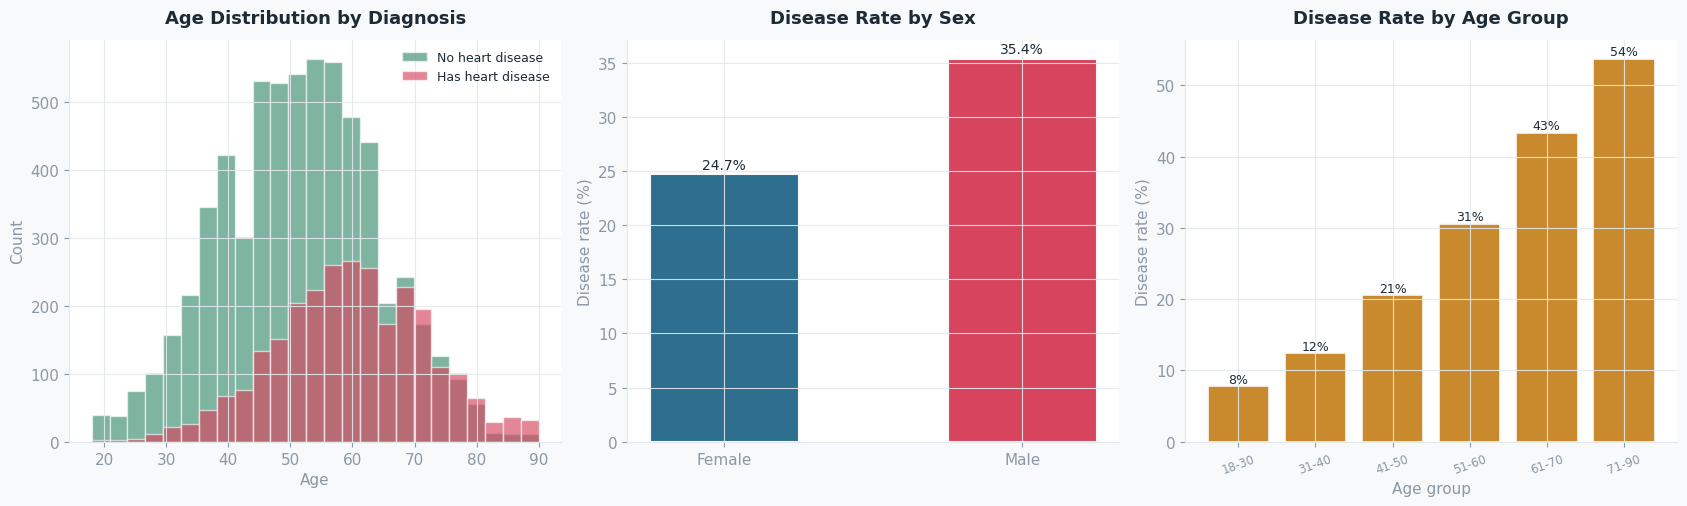

Disease rate rises steadily with age — the clearest, most expected demographic pattern in the dataset —
and runs meaningfully higher for men (35.4%) than women (24.7%),
consistent with well-documented real-world cardiovascular risk differences by sex.


In [5]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
for status, c in DISEASE_COLORS.items():
    ax.hist(df[df.has_heart_disease==status]['age'], bins=25, alpha=0.65, color=c,
            label='Has heart disease' if status else 'No heart disease', edgecolor=BG)
style_ax(ax, 'Age Distribution by Diagnosis', 'Age', 'Count')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
sex_rate = df.groupby('sex')['has_heart_disease'].mean()*100
bars = ax.bar(sex_rate.index, sex_rate.values, color=[BLUE, RED], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.1f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Disease Rate by Sex', '', 'Disease rate (%)')

ax = axes[2]
age_bins = pd.cut(df['age'], bins=[17,30,40,50,60,70,90], labels=['18-30','31-40','41-50','51-60','61-70','71-90'])
age_rate = df.groupby(age_bins, observed=True)['has_heart_disease'].mean()*100
bars = ax.bar(age_rate.index.astype(str), age_rate.values, color=AMBER, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Disease Rate by Age Group', 'Age group', 'Disease rate (%)')
plt.setp(ax.get_xticklabels(), rotation=20, fontsize=8.5)

plt.tight_layout()
plt.show()

print("Disease rate rises steadily with age — the clearest, most expected demographic pattern in the dataset —")
print(f"and runs meaningfully higher for men ({sex_rate['Male']:.1f}%) than women ({sex_rate['Female']:.1f}%),")
print("consistent with well-documented real-world cardiovascular risk differences by sex.")


<h2 id="clinical" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">🩺 5. Clinical Measurements Overview</h2>

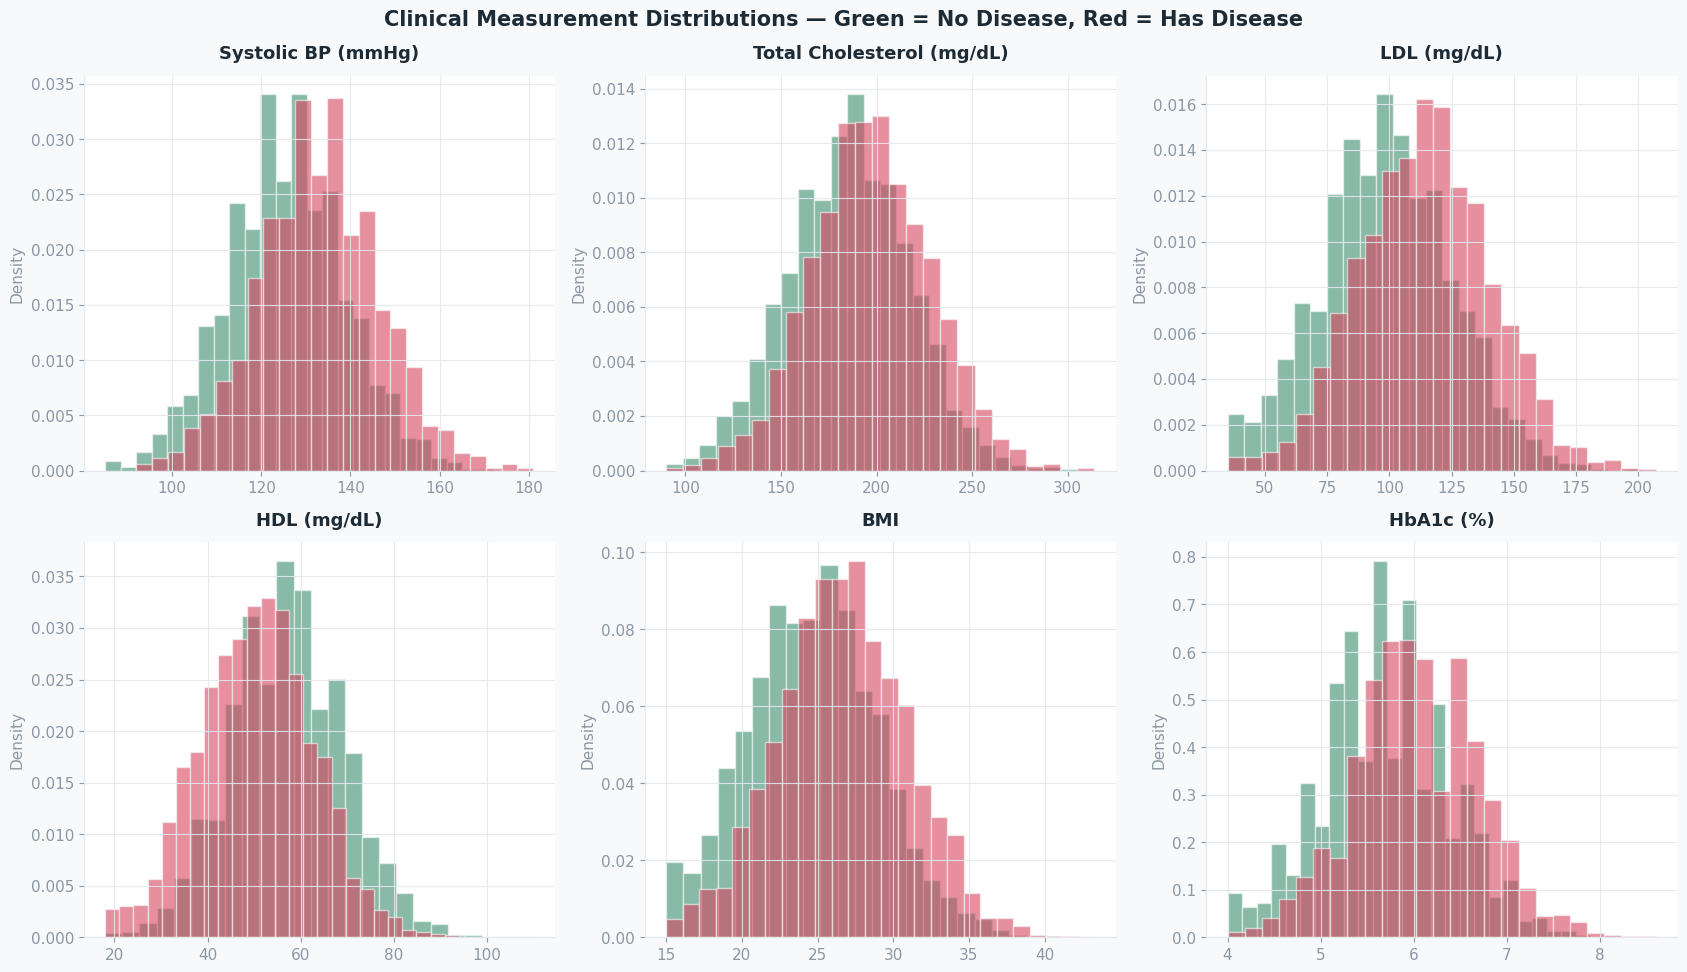

In [6]:

fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))
clinical_fields = ['resting_bp_systolic','cholesterol_total','ldl','hdl','bmi','hba1c']
titles = ['Systolic BP (mmHg)','Total Cholesterol (mg/dL)','LDL (mg/dL)','HDL (mg/dL)','BMI','HbA1c (%)']

for ax, field, title in zip(axes.flat, clinical_fields, titles):
    for status, c in DISEASE_COLORS.items():
        ax.hist(df[df.has_heart_disease==status][field], bins=25, alpha=0.6, color=c, density=True, edgecolor=BG)
    style_ax(ax, title, '', 'Density')

plt.tight_layout()
plt.suptitle('Clinical Measurement Distributions — Green = No Disease, Red = Has Disease', y=1.02, fontsize=15, color=INK, fontweight='bold')
plt.show()


<h2 id="drivers" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">📈 6. The Strongest Risk Signals</h2>

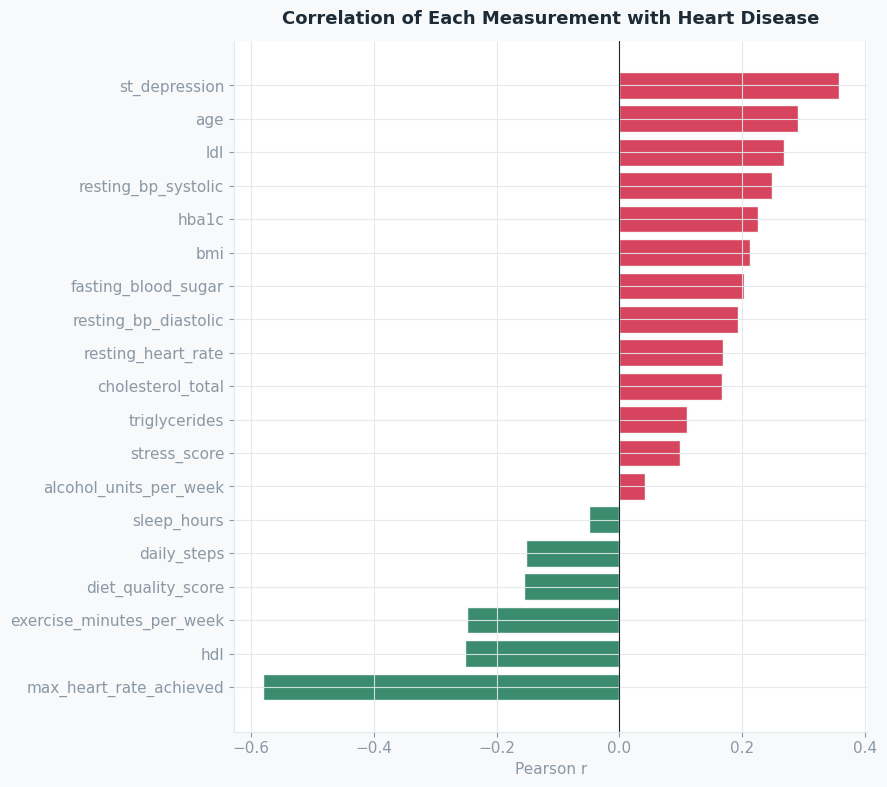

Max heart rate achieved (during a stress test) shows by far the strongest relationship (r≈-0.58) —
lower achievable heart rate under exertion is a well-known clinical marker of reduced cardiac fitness.
ST depression, LDL, age and blood pressure follow, all in the clinically expected direction.


In [7]:

num_cols = ['age','resting_bp_systolic','resting_bp_diastolic','cholesterol_total','hdl','ldl',
            'triglycerides','fasting_blood_sugar','hba1c','bmi','resting_heart_rate','max_heart_rate_achieved',
            'st_depression','alcohol_units_per_week','exercise_minutes_per_week','sleep_hours','stress_score',
            'daily_steps','diet_quality_score']
corrs = df[num_cols].corrwith(df['has_heart_disease']).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
colors = [GREEN if v<0 else RED for v in corrs.values]
bars = ax.barh(corrs.index, corrs.values, color=colors, edgecolor=BG, linewidth=1.0)
ax.axvline(0, color=INK, linewidth=0.8)
style_ax(ax, 'Correlation of Each Measurement with Heart Disease', 'Pearson r', '')
plt.tight_layout()
plt.show()

print("Max heart rate achieved (during a stress test) shows by far the strongest relationship (r≈-0.58) —")
print("lower achievable heart rate under exertion is a well-known clinical marker of reduced cardiac fitness.")
print("ST depression, LDL, age and blood pressure follow, all in the clinically expected direction.")


<h2 id="categorical" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">🚬 7. Categorical Risk Factors</h2>

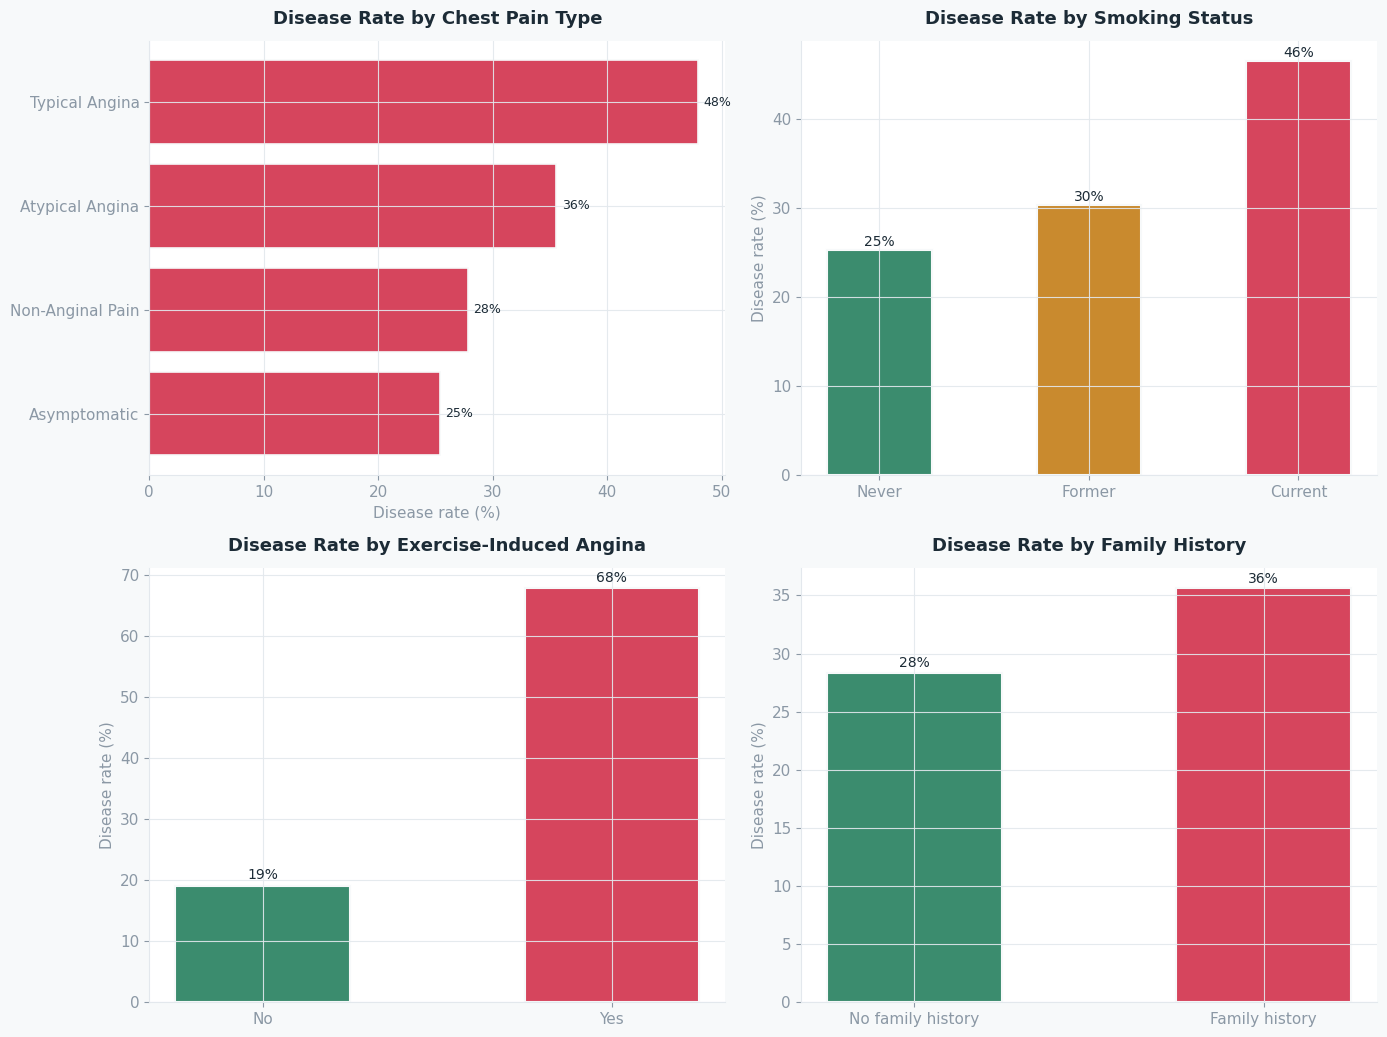

Exercise-induced angina shows the sharpest split of any categorical factor: 68% disease
rate vs. 19% — a dramatic, clinically sensible gap. Smoking shows a clean dose-response
pattern (never < former < current), and chest pain type orders sensibly from Asymptomatic (lowest) to
Typical Angina (highest) — the clinically intuitive direction.


In [8]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))

ax = axes[0,0]
cp_rate = df.groupby('chest_pain_type')['has_heart_disease'].mean().sort_values()*100
bars = ax.barh(cp_rate.index, cp_rate.values, color=RED, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f"{b.get_width():.0f}%", va='center', fontsize=9, color=INK)
style_ax(ax, 'Disease Rate by Chest Pain Type', 'Disease rate (%)', '')

ax = axes[0,1]
smoke_rate = df.groupby('smoker_status')['has_heart_disease'].mean().reindex(['Never','Former','Current'])*100
bars = ax.bar(smoke_rate.index, smoke_rate.values, color=[GREEN, AMBER, RED], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Disease Rate by Smoking Status', '', 'Disease rate (%)')

ax = axes[1,0]
angina_rate = df.groupby('exercise_induced_angina')['has_heart_disease'].mean()*100
bars = ax.bar(['No', 'Yes'], angina_rate.values, color=[GREEN, RED], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.0f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Disease Rate by Exercise-Induced Angina', '', 'Disease rate (%)')

ax = axes[1,1]
fh_rate = df.groupby('family_history')['has_heart_disease'].mean()*100
bars = ax.bar(['No family history', 'Family history'], fh_rate.values, color=[GREEN, RED], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Disease Rate by Family History', '', 'Disease rate (%)')

plt.tight_layout()
plt.show()

print(f"Exercise-induced angina shows the sharpest split of any categorical factor: {angina_rate[True]:.0f}% disease")
print(f"rate vs. {angina_rate[False]:.0f}% — a dramatic, clinically sensible gap. Smoking shows a clean dose-response")
print("pattern (never < former < current), and chest pain type orders sensibly from Asymptomatic (lowest) to")
print("Typical Angina (highest) — the clinically intuitive direction.")


<h2 id="lifestyle" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">🏃 8. Lifestyle Factors</h2>

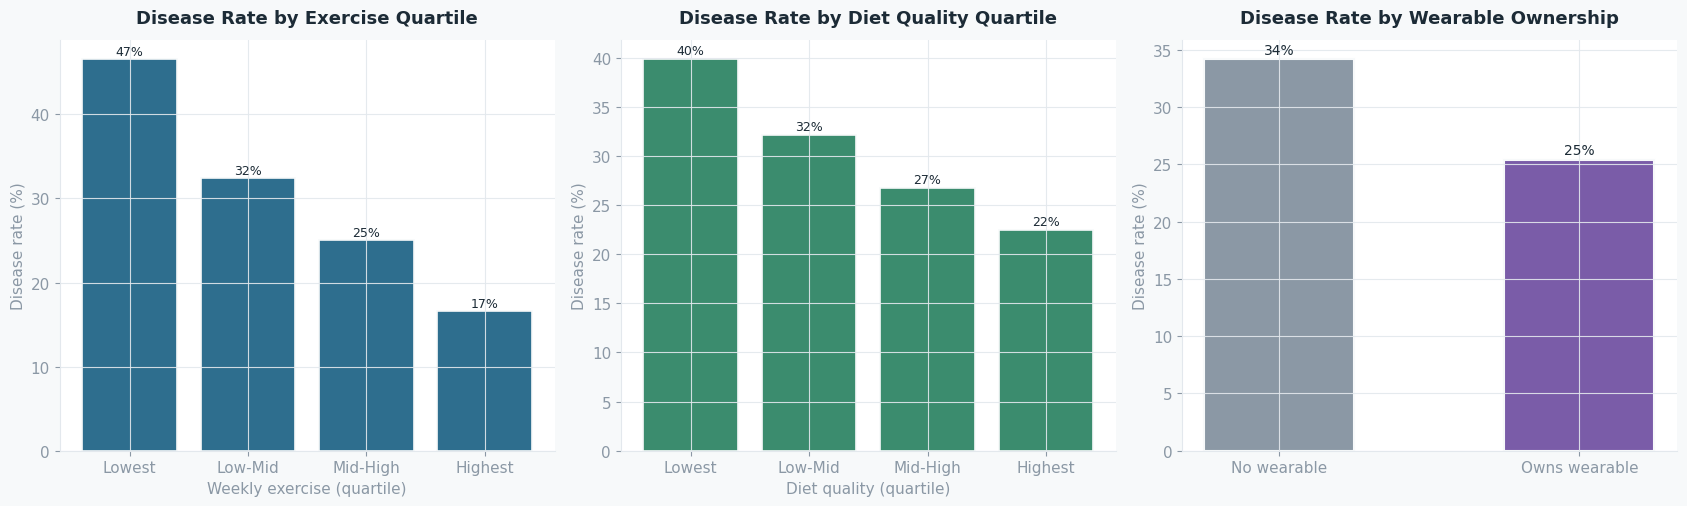

More exercise and better diet quality both associate with lower disease rates in a clean step-down pattern.
Wearable owners show a lower disease rate too — plausibly a health-consciousness confound (people who track
their health may also exercise more and eat better) rather than owning a device itself protecting anyone.


In [9]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
exercise_bins = pd.qcut(df['exercise_minutes_per_week'], 4, labels=['Lowest','Low-Mid','Mid-High','Highest'])
ex_rate = df.groupby(exercise_bins, observed=True)['has_heart_disease'].mean()*100
bars = ax.bar(ex_rate.index.astype(str), ex_rate.values, color=BLUE, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Disease Rate by Exercise Quartile', 'Weekly exercise (quartile)', 'Disease rate (%)')

ax = axes[1]
diet_bins = pd.qcut(df['diet_quality_score'], 4, labels=['Lowest','Low-Mid','Mid-High','Highest'])
diet_rate = df.groupby(diet_bins, observed=True)['has_heart_disease'].mean()*100
bars = ax.bar(diet_rate.index.astype(str), diet_rate.values, color=GREEN, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Disease Rate by Diet Quality Quartile', 'Diet quality (quartile)', 'Disease rate (%)')

ax = axes[2]
wearable_rate = df.groupby('wearable_owner')['has_heart_disease'].mean()*100
bars = ax.bar(['No wearable', 'Owns wearable'], wearable_rate.values, color=[INK_SOFT, PURPLE], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Disease Rate by Wearable Ownership', '', 'Disease rate (%)')

plt.tight_layout()
plt.show()

print("More exercise and better diet quality both associate with lower disease rates in a clean step-down pattern.")
print("Wearable owners show a lower disease rate too — plausibly a health-consciousness confound (people who track")
print("their health may also exercise more and eat better) rather than owning a device itself protecting anyone.")


<h2 id="corr" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">🔗 9. Correlation Check</h2>

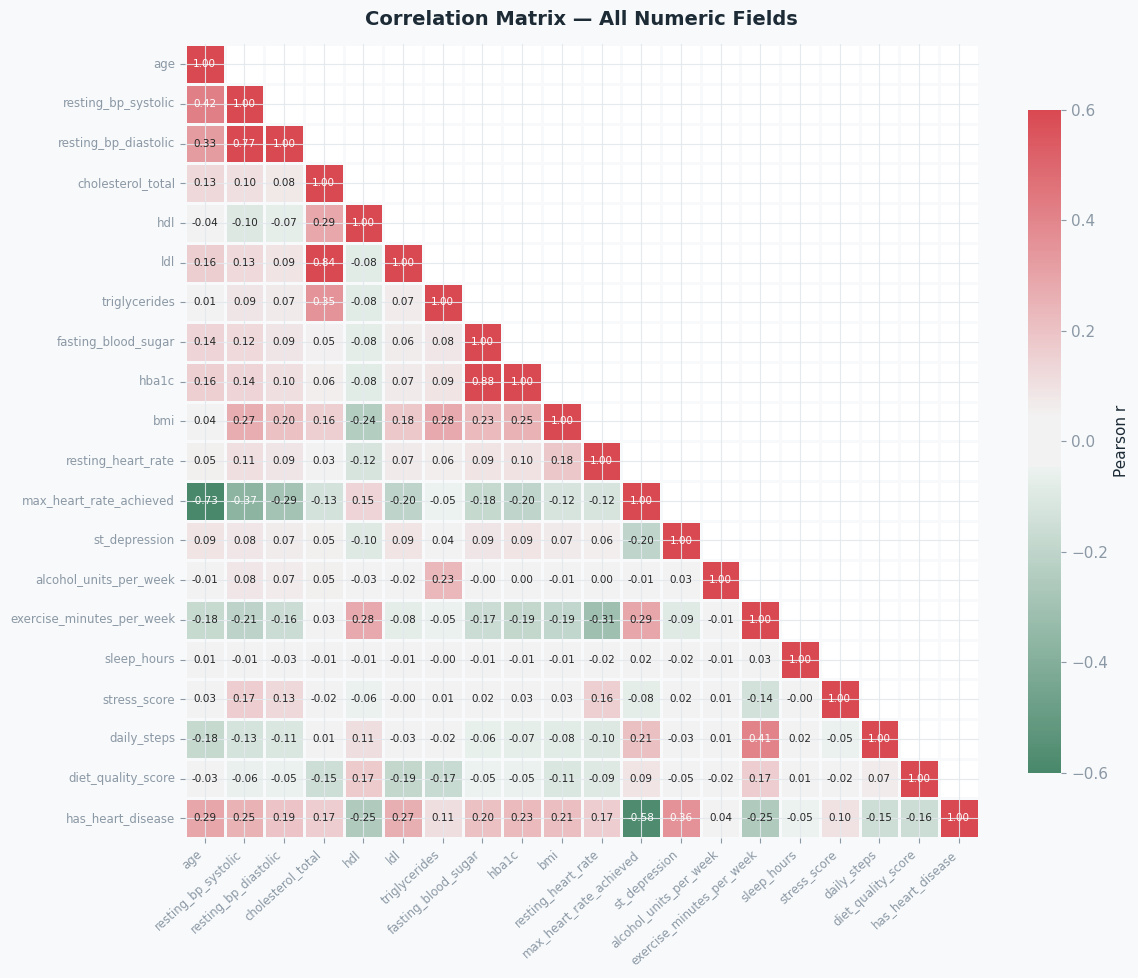

In [10]:

corr = df[num_cols + ['has_heart_disease']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
cmap = sns.diverging_palette(150, 10, s=65, l=52, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.6, vmax=0.6,
            square=True, linewidths=1.0, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':7.5}, ax=ax)
ax.set_title('Correlation Matrix — All Numeric Fields', color=INK, pad=14)
plt.xticks(rotation=42, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.show()


<h2 id="dashboard" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">📊 10. Clinical Dashboard</h2>

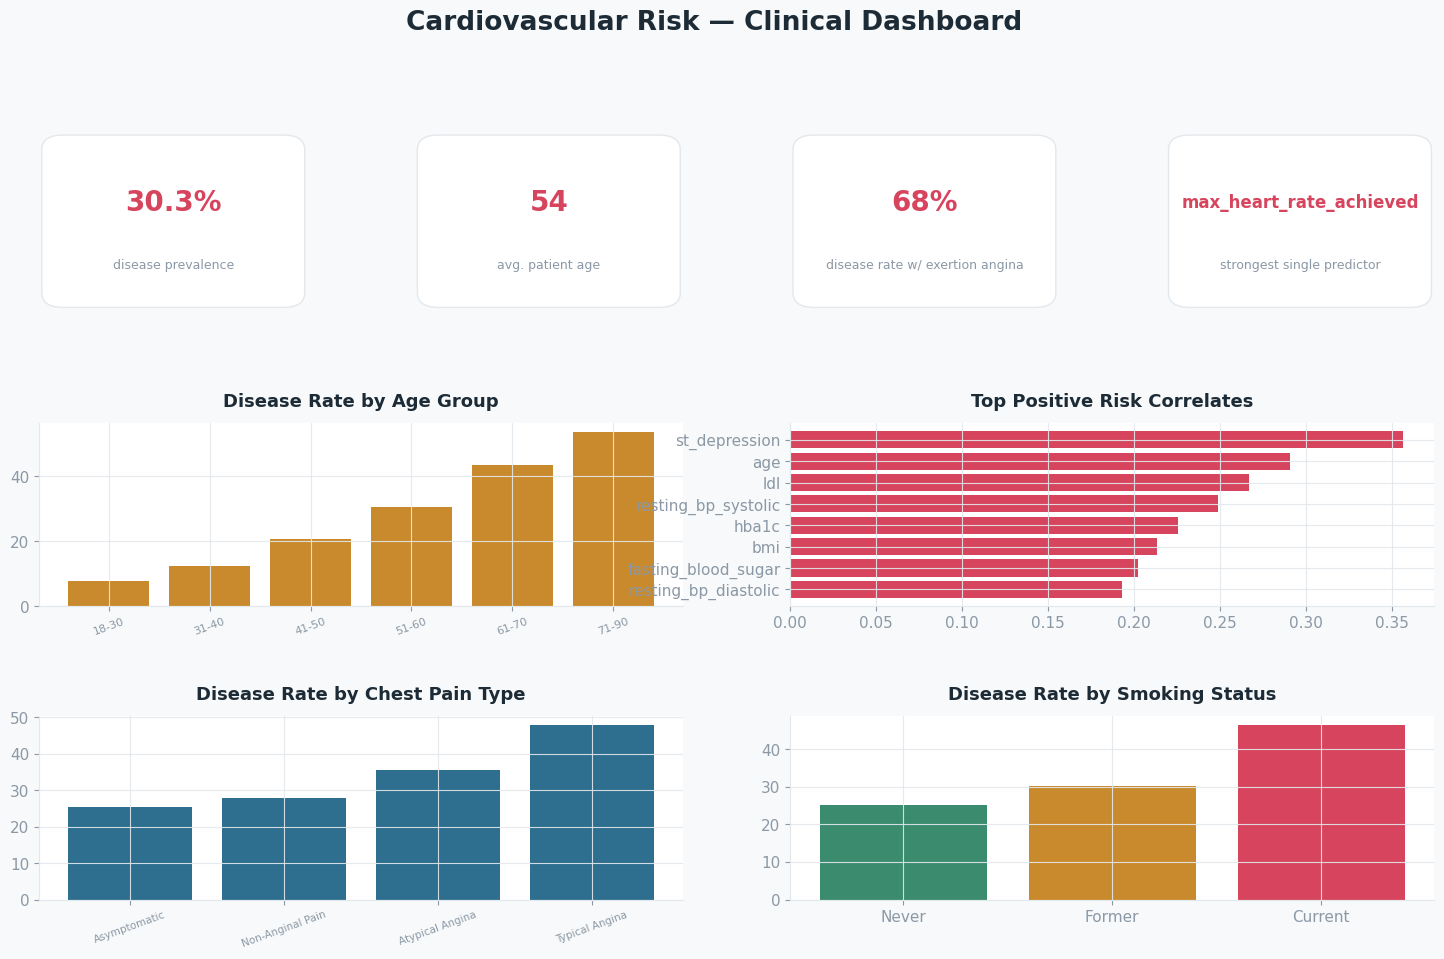

In [11]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Cardiovascular Risk — Clinical Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{df['has_heart_disease'].mean()*100:.1f}%", "disease prevalence"),
    (f"{df['age'].mean():.0f}", "avg. patient age"),
    (f"{angina_rate[True]:.0f}%", "disease rate w/ exertion angina"),
    (f"{corrs.abs().idxmax()}", "strongest single predictor"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.08",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    fs = 20 if len(str(val)) < 8 else 12
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=fs, color=RED, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
bars = ax.bar(age_rate.index.astype(str), age_rate.values, color=AMBER)
style_ax(ax, 'Disease Rate by Age Group', '', '')
plt.setp(ax.get_xticklabels(), rotation=20, fontsize=8)

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(corrs.tail(8).index, corrs.tail(8).values, color=RED)
style_ax(ax, 'Top Positive Risk Correlates', '', '')

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(cp_rate.index, cp_rate.values, color=BLUE)
style_ax(ax, 'Disease Rate by Chest Pain Type', '', '')
plt.setp(ax.get_xticklabels(), rotation=20, fontsize=7.5)

ax = fig.add_subplot(gs[2, 2:])
bars = ax.bar(smoke_rate.index, smoke_rate.values, color=[GREEN, AMBER, RED])
style_ax(ax, 'Disease Rate by Smoking Status', '', '')

plt.show()


<h2 id="model" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36; border-bottom:3px solid #D6455D; padding-bottom:8px;">🤖 11. Classifying Heart Disease Risk</h2>
<p style="color:#333; font-family:'Segoe UI',Helvetica,Arial,sans-serif; background:#F7F9FA; padding:8px 18px; border-radius:8px;">A reminder: this model is trained to find patterns in this dataset for illustration, not to serve as a real diagnostic tool.</p>

In [12]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                              classification_report, confusion_matrix, accuracy_score)

model_df = df.copy()
cat_cols = ['sex','chest_pain_type','smoker_status']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])
for c in ['exercise_induced_angina','family_history','wearable_owner']:
    model_df[c] = model_df[c].astype(int)

features = ['age','sex','resting_bp_systolic','resting_bp_diastolic','cholesterol_total','hdl','ldl',
            'triglycerides','fasting_blood_sugar','hba1c','bmi','resting_heart_rate','max_heart_rate_achieved',
            'chest_pain_type','exercise_induced_angina','st_depression','family_history','smoker_status',
            'alcohol_units_per_week','exercise_minutes_per_week','sleep_hours','stress_score','wearable_owner',
            'daily_steps','diet_quality_score']
X = model_df[features]
y = model_df['has_heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), X_train_s, X_test_s),
    'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1), X_train, X_test),
    'XGBoost': (XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08, random_state=42, eval_metric='logloss'), X_train, X_test)
}

results = {}
for name, (m, Xtr, Xte) in models.items():
    m.fit(Xtr, y_train)
    proba = m.predict_proba(Xte)[:,1]
    pred = m.predict(Xte)
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    results[name] = {'model': m, 'proba': proba, 'pred': pred, 'auc': auc, 'acc': acc}
    print(f"{name}: ROC-AUC = {auc:.3f} | Accuracy = {acc:.3f}")


Logistic Regression: ROC-AUC = 0.948 | Accuracy = 0.896
Random Forest: ROC-AUC = 0.938 | Accuracy = 0.879
XGBoost: ROC-AUC = 0.942 | Accuracy = 0.887


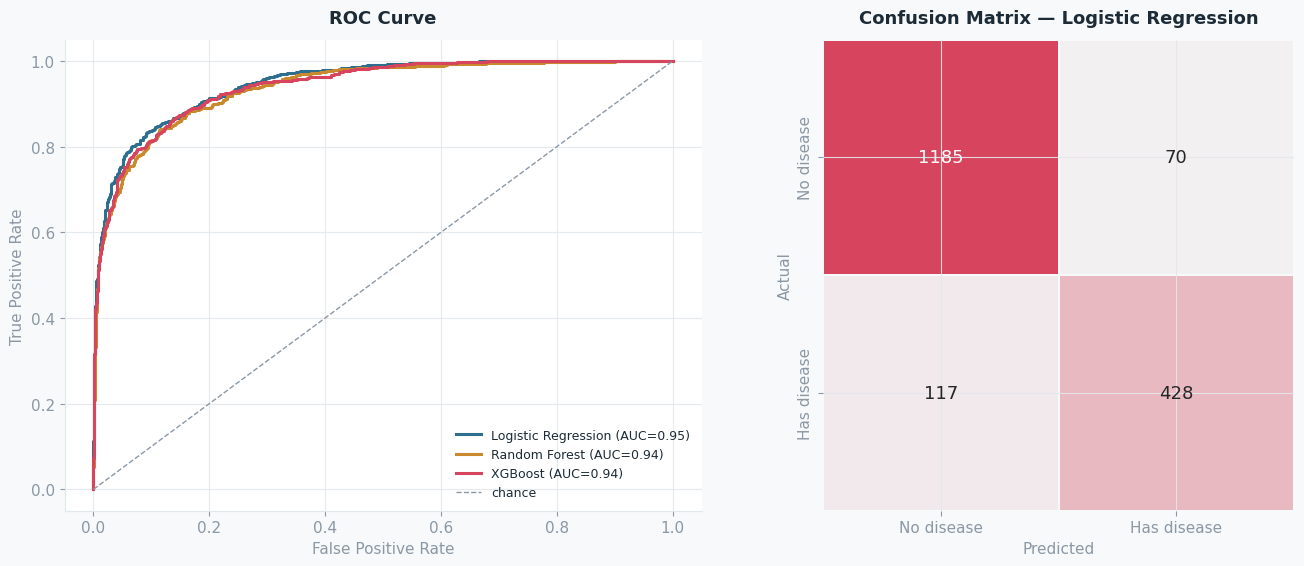

              precision    recall  f1-score   support

  No disease       0.91      0.94      0.93      1255
 Has disease       0.86      0.79      0.82       545

    accuracy                           0.90      1800
   macro avg       0.88      0.86      0.87      1800
weighted avg       0.89      0.90      0.89      1800



In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

ax = axes[0]
for (name, res), c in zip(results.items(), [BLUE, AMBER, RED]):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})", color=c, linewidth=2.2)
ax.plot([0,1],[0,1], linestyle='--', color=INK_SOFT, linewidth=1, label='chance')
style_ax(ax, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')
ax.legend(frameon=False, fontsize=9)

best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
cm = confusion_matrix(y_test, best['pred'])
ax = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(RED, as_cmap=True), square=True, cbar=False,
            xticklabels=['No disease','Has disease'], yticklabels=['No disease','Has disease'],
            linewidths=1.2, linecolor=BG, annot_kws={'fontsize':13}, ax=ax)
style_ax(ax, f'Confusion Matrix — {best_name}', 'Predicted', 'Actual')

plt.tight_layout()
plt.show()

print(classification_report(y_test, best['pred'], target_names=['No disease','Has disease']))


In [14]:

if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=features).sort_values().tail(15)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(importances.index, importances.values, color=RED, edgecolor=BG)
    style_ax(ax, f'Top 15 Feature Importances — {best_name}', 'Importance', '')
    plt.tight_layout()
    plt.show()



<div style="background:#F7F9FA; border-left:3px solid #2E6E8E; padding:14px 20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#333; font-size:14px; border-radius:6px;">
Max heart rate achieved, exercise-induced angina, ST depression, and age dominate feature importance — the same
handful of clinically meaningful markers identified in the correlation analysis. Strong, consistent agreement
between EDA and modeling is a good internal-validity signal, but the practical takeaway is about which factors
matter, not that this specific model should inform real medical decisions.
</div>



<div style="background:#F7F9FA; padding:36px 40px; border-radius:10px; border-left:4px solid #D6455D; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1C2B36;">

<h2 id="conclusion" style="margin-top:0; font-weight:700; color:#1C2B36; border-bottom:1px solid #E3E8ED; padding-bottom:10px;">📝 12. Closing Notes</h2>

<h4 style="color:#D6455D; font-weight:700; margin-bottom:6px;">What the data shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#333;">
<li>Max heart rate achieved under exertion is the single strongest predictor (r≈-0.58) — a well-established clinical marker of cardiac fitness.</li>
<li>Exercise-induced angina shows the sharpest categorical split (68% vs. 19% disease rate) of any factor in the dataset.</li>
<li>Age, sex, smoking status, chest pain type, LDL, blood pressure and HbA1c all move in clinically expected directions — a reassuring sign of internal consistency.</li>
<li>Lifestyle factors (exercise, diet quality) show a clean step-down pattern with disease rate, while wearable ownership's association likely reflects a health-consciousness confound rather than a protective effect of the device itself.</li>
<li>Classification models reach a strong, believable AUC using the same handful of clinically meaningful features identified in the EDA — good agreement between the exploratory and modeling stages.</li>
</ul>

<div style="margin-top:20px; padding:14px 18px; background:#FCEBEE; border-radius:8px;">
<p style="margin:0; font-size:13px; color:#7A2C38; line-height:1.6;">
As noted at the start: this is exploratory, educational analysis of a dataset — not a diagnostic tool, and not a
substitute for medical advice. Anyone with concerns about their own cardiovascular health should talk to a doctor.
</p>
</div>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8B98A5; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
